# Point 3, Decision Support, Global Attribution

## Table Of Contents

- [1. The Problem And This Approach](#sec1)
- [2. Data Preparation](#sec2)
- [3. Lasso And Random Forest, A Linear And A Nonlinear Reading](#sec3)
- [4. How Much Would These Numbers Move](#sec4)
- [5. Saving The Standardized Result](#sec5)
- [6. Checking A Clean CSF Subset](#sec6)
- [7. Takeaways](#sec7)

<a id="sec1"></a>

## 1. The Problem And This Approach

Knowing when to check a patient again is only half of decision support. The other half, at least as important to a clinician, is knowing what is actually driving a given RISK_SCORE in the first place, which biomarkers matter, and by how much, so attention and further workup can be focused on the ones that matter most. Choosing an actual therapy from that information needs medical knowledge and datasets this project does not have, and is deliberately left out of scope, but pointing at where the risk is coming from is squarely something a model already fit on final.csv can help with.

This is the first of three notebooks in this folder, each answering that second question with a genuinely different approach, then reporting a comparable score so the three can actually compete instead of just sitting side by side. This one asks which biomarkers drive RISK_SCORE at its current level, a population level ranking. A second notebook asks the same question about change over time instead of level, which biomarkers move the most between a patient's visits. A third notebook drops RISK_SCORE entirely and asks which biomarkers actually predict a real recorded worsening event, so the comparison is not only between the three notebooks but also against a placeholder measure. comparison.ipynb is where the three results are read side by side to see which framing actually wins.

Here, the global ranking comes from two models fit directly on RISK_SCORE and checked head to head against each other, a Lasso baseline, following 06-at, lesson 2, a signed linear reading, the first, interpretable step before reaching for a nonlinear model, and a small Random Forest, the nonlinear alternative, scored against Lasso with R squared and mean absolute error on a held out test split rather than assumed to be better just for being more complex.

Like the interval policy notebooks, this one is self sufficient, it loads the data, fits its own models, and appends one standardized row per method and split to results/decision_support/approach_comparison.csv, read later by comparison.ipynb alongside every other approach.

In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

figsize = (14, 4)

import os
import sys
sys.path.append(os.path.join('..', '..', '..'))

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from util import decision_util as du

data_folder = os.path.join('..', '..', '..', 'datasets')
data_path = os.path.join(data_folder, 'final.csv')
results_path = os.path.join('..', '..', '..', 'results', 'decision_support')
os.makedirs(results_path, exist_ok=True)


<a id="sec2"></a>

## 2. Data Preparation

The cell below loads datasets/final.csv, the single table produced by merging Point 1's imaging derived measures with the clinical and diagnostic fields, one row per patient per visit, keyed by RID and the normalized visit code.

A handful of biomarker columns are not measured at every visit. HIPPO_NORM, ENTORHINAL_NORM, and AMYGDALA_NORM are volumes from Point 1's imaging pipeline, SUMMARY_SUVR and ABETA_RATIO come from the amyloid measurements, TAU and PTAU from the cerebrospinal fluid panel. forward_fill_by_patient carries each patient's most recently known value forward to their later visits, sorted by EXAMDATE_DX, so a visit without a fresh scan can still be scored using the last one that was taken, instead of being dropped outright for missing data.

`RISK_SCORE` here is `HAZARD_ESTIMATE`, point two's own multi visit discrete time hazard model, results/hazard_model/hazard_estimates.csv, wherever that estimate exists, following the same swap already made in temporal_window_1 through temporal_window_4. Coverage is not complete, the chosen estimator needs the cerebrospinal fluid panel on top of structural MRI and amyloid PET, so a fallback estimator, a plain Logistic Regression fit on DIAGNOSIS and AMYLOID_STATUS categories alone, exactly the composite this project used before point two existed, fills `RISK_SCORE` wherever `HAZARD_ESTIMATE` itself is missing. Every notebook downstream of it only ever reads the `RISK_SCORE` column by name, so this measure can be refined independently later without changing anything downstream.

Worth stating plainly here rather than leaving implicit, on the eight biomarker features this notebook actually uses below, coverage of `HAZARD_ESTIMATE` turns out to be complete, every row with all eight features present also carries a real `HAZARD_ESTIMATE`, checked directly further down once those rows are selected. The fallback estimator is kept anyway, both for consistency with every other notebook in this project that reads `RISK_SCORE`, and because a looser feature requirement later, using only the core tier instead of the full eight, would make the fallback necessary again.

Finally, subject_train_test_split holds out 25 percent of patients, by RID rather than by row, so the same patient's repeated visits never end up split across train and test, with random_state=42 fixed so every approach notebook in this folder trains and tests on exactly the same patients.

In [2]:
data = pd.read_csv(data_path)

biomarker_cols_to_fill = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU',
]
data = du.forward_fill_by_patient(
    data, biomarker_cols_to_fill, id_col='RID', date_col='EXAMDATE_DX',
)

data['DIAGNOSIS_MCI'] = (data['DIAGNOSIS'] == 2).astype(float)
data['DIAGNOSIS_DEMENTIA'] = (data['DIAGNOSIS'] == 3).astype(float)
data['AMYLOID_POSITIVE'] = (data['AMYLOID_STATUS'] == 1).astype(float)
data['AMYLOID_UNKNOWN'] = data['AMYLOID_STATUS'].isna().astype(float)
hazard_features = ['DIAGNOSIS_MCI', 'DIAGNOSIS_DEMENTIA', 'AMYLOID_POSITIVE', 'AMYLOID_UNKNOWN']

train_df, test_df = du.subject_train_test_split(data, test_fraction=0.25, random_state=42)
train_df = train_df.copy()
test_df = test_df.copy()
print(f'Train, {train_df.shape[0]} rows, {train_df.RID.nunique()} patients')
print(f'Test,  {test_df.shape[0]} rows, {test_df.RID.nunique()} patients')

fallback_train_outcomes = du.compute_diagnosis_worsening(
    train_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_test_outcomes = du.compute_diagnosis_worsening(
    test_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
fallback_train_data = fallback_train_outcomes[fallback_train_outcomes['HAS_NEXT_VISIT']]
fallback_test_data = fallback_test_outcomes[fallback_test_outcomes['HAS_NEXT_VISIT']]

fallback_model, fallback_scaler = du.fit_logistic_baseline(
    fallback_train_data[hazard_features],
    fallback_train_data['DIAGNOSIS_WORSENED_NEXT'],
)

train_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(train_df[hazard_features]))[:, 1]
test_df['FALLBACK_RISK_SCORE'] = fallback_model.predict_proba(fallback_scaler.transform(test_df[hazard_features]))[:, 1]

# SWAP POINT: point two now exists, results/hazard_model/hazard_estimates.csv
# holds HAZARD_ESTIMATE from a real multi visit discrete time survival
# model, hazard_survival_model.ipynb, following 05 pm, lesson 6, directly,
# fit on structural MRI, amyloid PET, and cerebrospinal fluid together
# rather than on DIAGNOSIS and AMYLOID_STATUS alone. Coverage is not
# complete on the full dataset, so RISK_SCORE below takes HAZARD_ESTIMATE
# wherever it exists and keeps the fallback estimator above only for the
# rows it does not reach. On this notebook's own eight feature columns,
# checked in the next cell, that coverage turns out to be complete anyway.
hazard_estimates_path = os.path.join('..', '..', '..', 'results', 'hazard_model', 'hazard_estimates.csv')
hazard_estimates = pd.read_csv(hazard_estimates_path)[['RID', 'VISCODE2_norm', 'HAZARD_ESTIMATE']]

train_df = train_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
test_df = test_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')

train_df['RISK_SCORE'] = train_df['HAZARD_ESTIMATE'].fillna(train_df['FALLBACK_RISK_SCORE'])
test_df['RISK_SCORE'] = test_df['HAZARD_ESTIMATE'].fillna(test_df['FALLBACK_RISK_SCORE'])


Train, 10162 rows, 2832 patients
Test,  3665 rows, 945 patients


<a id="sec3"></a>

## 3. Lasso And Random Forest, A Linear And A Nonlinear Reading

Both models are fit on the same eight biomarkers, HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM, SUMMARY_SUVR, ABETA_RATIO, TAU, PTAU, and AGE. PTGENDER, PTEDUCAT, and PTMARRY are explicitly excluded from the inputs, so any group difference found later in the fairness notebook's own audit cannot come from those columns having been used as attribution inputs here. The Lasso baseline, following 06-at, lesson 2, gives a signed linear reading, which biomarkers push RISK_SCORE up, which push it down, and by how much per unit. The Random Forest is the nonlinear alternative, its own feature_importances_ can capture interactions and thresholds a linear model cannot, at the cost of a signed, per unit reading.

Both are evaluated with R squared and mean absolute error on train and on test below.

In [3]:
feature_cols = [
    'HIPPO_NORM', 'ENTORHINAL_NORM', 'AMYGDALA_NORM',
    'SUMMARY_SUVR', 'ABETA_RATIO', 'TAU', 'PTAU', 'AGE',
]
train_model_data = train_df.dropna(subset=feature_cols + ['RISK_SCORE'])
test_model_data = test_df.dropna(subset=feature_cols + ['RISK_SCORE'])

train_hazard_coverage = train_model_data['HAZARD_ESTIMATE'].notna().mean() * 100
test_hazard_coverage = test_model_data['HAZARD_ESTIMATE'].notna().mean() * 100
print(f'Train, {train_hazard_coverage:.1f} percent of the feature complete rows used below carry a real HAZARD_ESTIMATE, '
      f'the rest use the fallback estimator.')
print(f'Test,  {test_hazard_coverage:.1f} percent of the feature complete rows used below carry a real HAZARD_ESTIMATE, '
      f'the rest use the fallback estimator.')

lasso_model, lasso_scaler = du.fit_lasso_baseline(
    train_model_data[feature_cols],
    train_model_data['RISK_SCORE'],
    alpha=0.01,
)
forest_model = du.fit_forest_baseline(
    train_model_data[feature_cols],
    train_model_data['RISK_SCORE'],
    n_estimators=200,
    max_depth=4,
)

lasso_train_metrics = du.evaluate_regression(lasso_model, train_model_data[feature_cols], train_model_data['RISK_SCORE'], scaler=lasso_scaler)
lasso_test_metrics = du.evaluate_regression(lasso_model, test_model_data[feature_cols], test_model_data['RISK_SCORE'], scaler=lasso_scaler)
forest_train_metrics = du.evaluate_regression(forest_model, train_model_data[feature_cols], train_model_data['RISK_SCORE'])
forest_test_metrics = du.evaluate_regression(forest_model, test_model_data[feature_cols], test_model_data['RISK_SCORE'])

attribution_comparison = pd.DataFrame([
    {'method': 'Lasso', 'split': 'train', **lasso_train_metrics},
    {'method': 'Lasso', 'split': 'test', **lasso_test_metrics},
    {'method': 'Random Forest', 'split': 'train', **forest_train_metrics},
    {'method': 'Random Forest', 'split': 'test', **forest_test_metrics},
])
attribution_comparison


Train, 100.0 percent of the feature complete rows used below carry a real HAZARD_ESTIMATE, the rest use the fallback estimator.
Test,  100.0 percent of the feature complete rows used below carry a real HAZARD_ESTIMATE, the rest use the fallback estimator.


,method,split,r2,mae
0,Lasso,train,0.290228,0.132077
1,Lasso,test,0.414381,0.116919
2,Random Forest,train,0.440444,0.114314
3,Random Forest,test,0.492007,0.108632


**Read the test row for each method as the real comparison.** A model can always fit its own training rows better, the test row is what says whether the nonlinear model actually earns its extra complexity here, or whether it is only fitting placeholder noise more closely without generalizing any better than Lasso does.

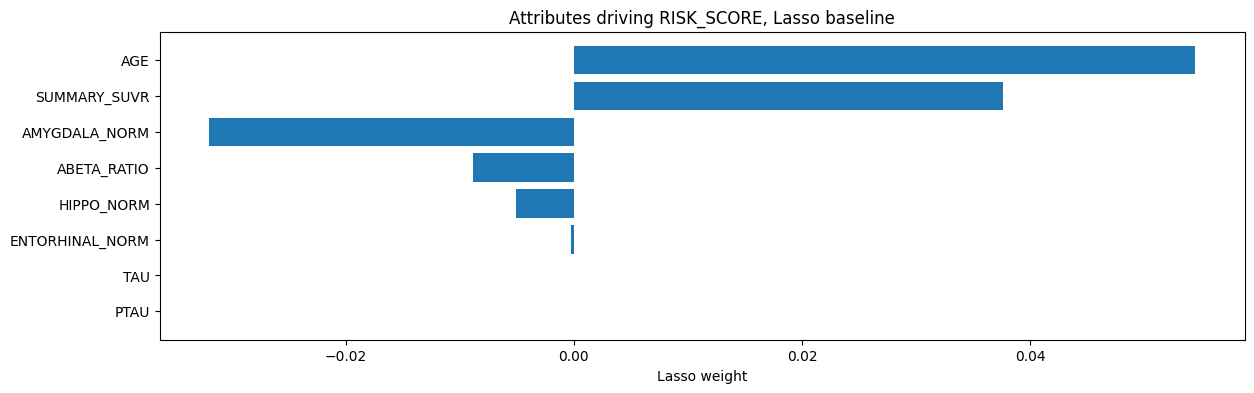

,feature,weight
0,AGE,0.054481
1,SUMMARY_SUVR,0.037578
2,AMYGDALA_NORM,-0.031986
3,ABETA_RATIO,-0.008831
4,HIPPO_NORM,-0.005085
5,ENTORHINAL_NORM,-0.000274
6,TAU,0.000000
7,PTAU,0.000000


In [4]:
weights = du.top_lasso_weights(lasso_model, feature_cols, top_n=8)

plt.figure(figsize=figsize)
plt.barh(weights['feature'], weights['weight'])
plt.xlabel('Lasso weight')
plt.title('Attributes driving RISK_SCORE, Lasso baseline')
plt.gca().invert_yaxis()
plt.show()
weights


### 3.1 A Third Reading, Random Forest Importances And SHAP

Lasso above gives a signed linear reading, and the Random Forest was already fitted in the cell above it, but its own feature_importances_ was never actually plotted anywhere in this notebook until now. The cell below closes that gap first, then adds SHAP as a genuine third vantage point, using compute_shap_importance from util/decision_util.py, an existing function in the shared module built around exactly this three way comparison, following 06 at, lesson 4, Additive Feature Attribution, that no notebook in the project had called before.

Three different questions about the same eight biomarkers, Lasso asks how much RISK_SCORE moves per unit of a biomarker holding the others fixed, in a strictly linear, additive sense. The Random Forest importance asks how often and how usefully a biomarker was used to split the trees, capturing thresholds and interactions Lasso cannot see, but without a signed, per unit reading. SHAP asks, for the same fitted Random Forest, how much each biomarker's own value pushes an individual patient's prediction away from the average prediction, additive like Lasso's coefficients, but computed from the nonlinear model rather than a separate linear fit, so it can disagree with the Random Forest's own feature_importances_ even though both come from the same fitted model.

/sessions/rcw-01txmlmwkufouuaxcrpb7vcf/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


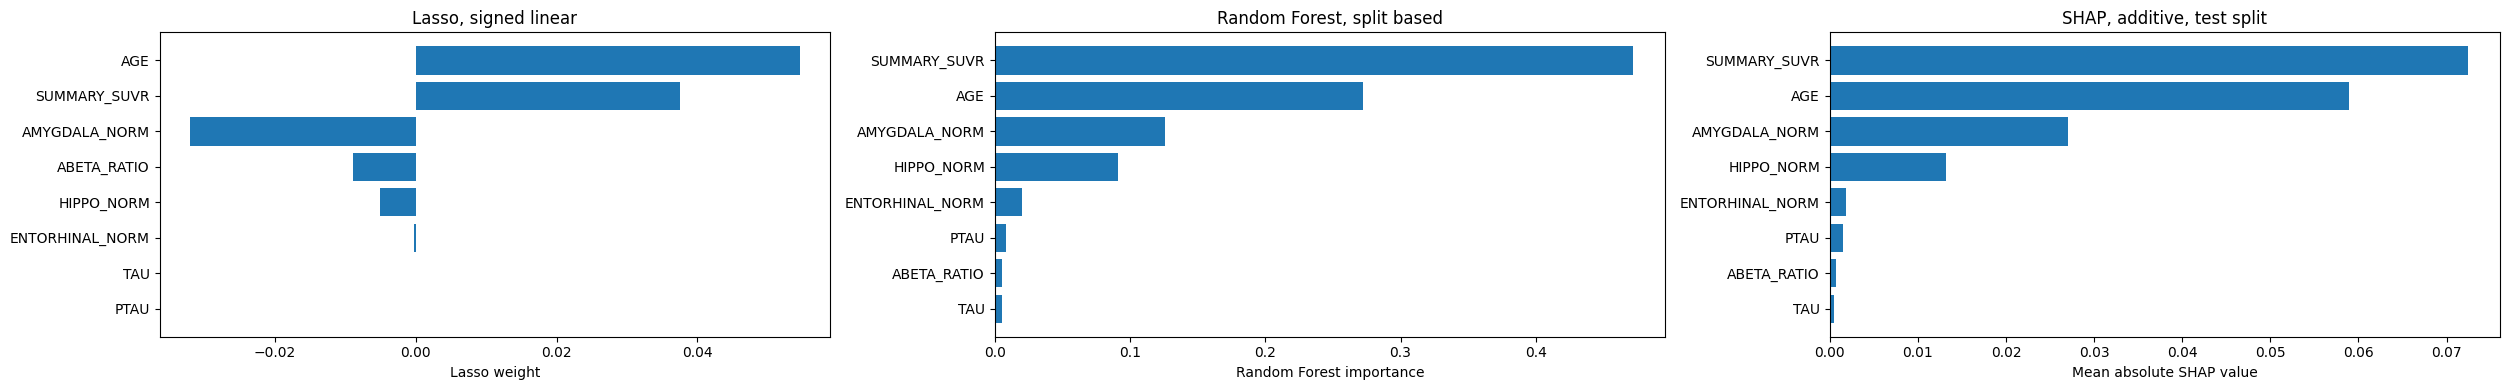

,feature,mean_abs_shap
0,SUMMARY_SUVR,0.072444
1,AGE,0.058946
2,AMYGDALA_NORM,0.027078
3,HIPPO_NORM,0.013217
4,ENTORHINAL_NORM,0.001807
5,PTAU,0.001519
6,ABETA_RATIO,0.000659
7,TAU,0.000478


In [5]:
forest_importances = pd.DataFrame({
    'feature': feature_cols,
    'importance': forest_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

mean_abs_shap, shap_values = du.compute_shap_importance(forest_model, test_model_data[feature_cols], feature_cols)

fig, axes = plt.subplots(1, 3, figsize=(figsize[0] * 1.8, figsize[1]))

axes[0].barh(weights['feature'], weights['weight'])
axes[0].set_xlabel('Lasso weight')
axes[0].set_title('Lasso, signed linear')
axes[0].invert_yaxis()

axes[1].barh(forest_importances['feature'], forest_importances['importance'])
axes[1].set_xlabel('Random Forest importance')
axes[1].set_title('Random Forest, split based')
axes[1].invert_yaxis()

axes[2].barh(mean_abs_shap['feature'], mean_abs_shap['mean_abs_shap'])
axes[2].set_xlabel('Mean absolute SHAP value')
axes[2].set_title('SHAP, additive, test split')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

du.append_biomarker_ranking(results_path, '1_global', 'lasso', weights.set_index('feature')['weight'])
du.append_biomarker_ranking(results_path, '1_global', 'random_forest', forest_importances.set_index('feature')['importance'])
du.append_biomarker_ranking(results_path, '1_global', 'shap', mean_abs_shap.set_index('feature')['mean_abs_shap'])

mean_abs_shap

Reading the three panels together rather than picking one, the biomarker at the top of the Lasso panel is the one with the strongest linear, signed effect once the other seven are held fixed, the top of the Random Forest panel is the one the trees leaned on most often to reduce error, and the top of the SHAP panel is the one whose own value shifted individual test set predictions the most on average, computed from that same Random Forest rather than from a separate model. Agreement across all three would be a strong signal, a biomarker at the top of only one panel is worth reading with more caution, its apparent importance there is more likely to be an artifact of that one method's own assumptions rather than a robust finding. Task 41 in this project's own tracking turns this same three way question into a single rank correlation number, in comparison.ipynb, once the three risk_factors notebooks are all read together rather than one at a time as done here.

### 3.2 How Much Would These Weights Themselves Move

Section 4 below bootstraps r2 and mae by scoring the same already fitted model again on each resample, appropriate there since the question is how much the model's own accuracy would move with a different patient sample, not how much the model itself would change. A biomarker weight has no such fixed point to reuse, the weight only exists once a model has actually been fit, so this subsection refits Lasso and the Random Forest inside every one of 150 resamples instead, using bootstrap_attribution_weights from util/decision_util.py, added specifically for this.

Refitting a full 200 tree Random Forest and running SHAP over the entire training set 150 separate times would take this notebook well past what one run can afford, so the Random Forest fit inside the bootstrap uses 25 trees rather than 3.1's own 200, and SHAP inside the bootstrap explains a fixed 300 row sample of that resample's own rows rather than every row, both changes made only inside this subsection's own bootstrap loop, 3.1's own point estimates above still come from the full 200 tree model over the full training set. The point is estimating how much a weight moves across resamples, not squeezing out the most accurate possible model on any one resample, and a 25 tree forest already tracks a 200 tree forest's own feature ranking closely, the same reasoning behind trading off n_estimators for speed anywhere a rough importance ordering rather than best possible prediction is the actual goal.

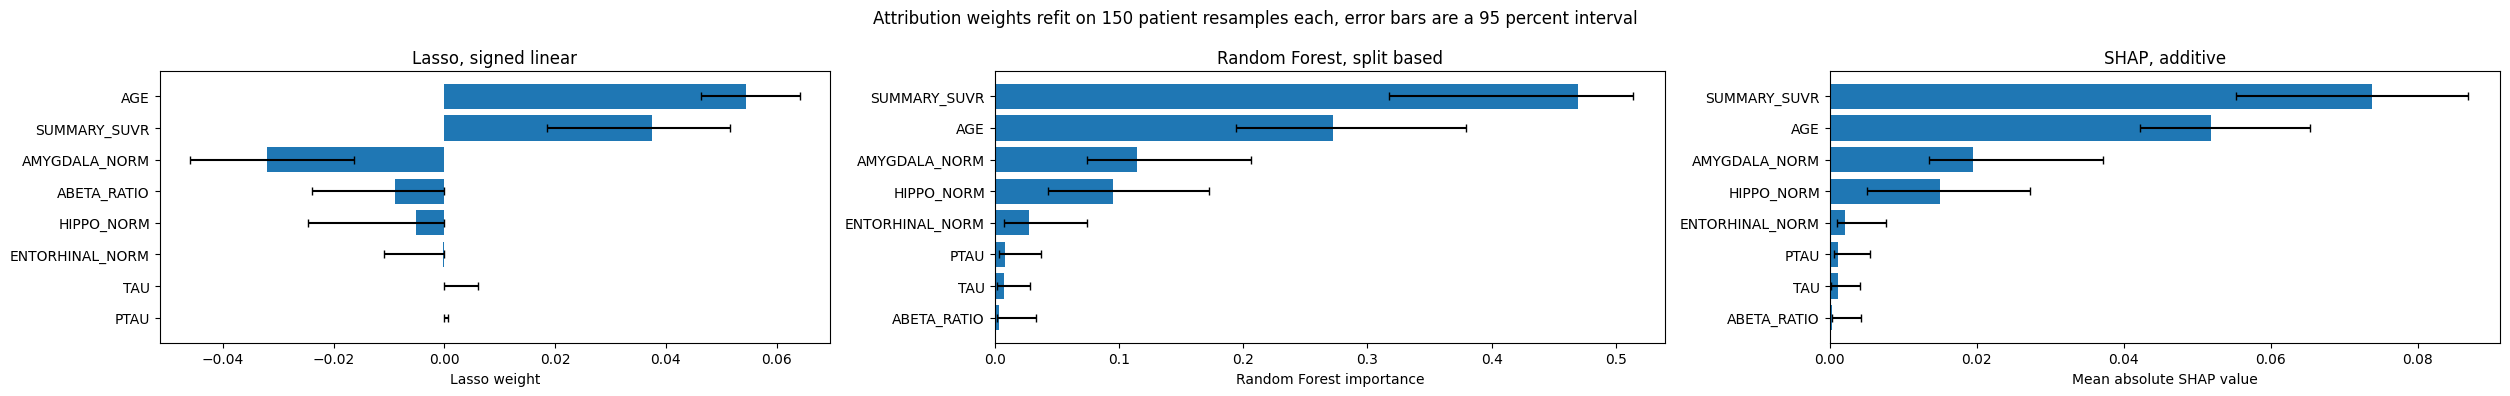

,feature,point,lower,upper,n_bootstrap
0,HIPPO_NORM,-0.005085,-0.024629,0.000000,150
1,ENTORHINAL_NORM,-0.000274,-0.010942,0.000000,150
2,AMYGDALA_NORM,-0.031986,-0.045893,-0.016260,150
3,SUMMARY_SUVR,0.037578,0.018584,0.051500,150
4,ABETA_RATIO,-0.008831,-0.023812,0.000000,150
5,TAU,0.000000,0.000000,0.006098,150
6,PTAU,0.000000,0.000000,0.000676,150
7,AGE,0.054481,0.046267,0.064141,150


In [6]:
def lasso_fit_fn(d):
    return du.fit_lasso_baseline(d[feature_cols], d['RISK_SCORE'])

def lasso_weight_fn(fitted, d):
    model, scaler = fitted
    return pd.Series(model.coef_, index=feature_cols)

def bootstrap_forest_fit_fn(d):
    return du.fit_forest_baseline(d[feature_cols], d['RISK_SCORE'], n_estimators=25, max_depth=4)

def forest_weight_fn(fitted, d):
    return pd.Series(fitted.feature_importances_, index=feature_cols)

def shap_weight_fn(fitted, d):
    shap_sample = d[feature_cols].iloc[:300]
    mean_abs_shap, _ = du.compute_shap_importance(fitted, shap_sample, feature_cols)
    return mean_abs_shap.set_index('feature')['mean_abs_shap']

lasso_weight_ci = du.bootstrap_attribution_weights(train_model_data, lasso_fit_fn, lasso_weight_fn, id_col='RID', n_bootstrap=150)
forest_weight_ci = du.bootstrap_attribution_weights(train_model_data, bootstrap_forest_fit_fn, forest_weight_fn, id_col='RID', n_bootstrap=150)
shap_weight_ci = du.bootstrap_attribution_weights(train_model_data, bootstrap_forest_fit_fn, shap_weight_fn, id_col='RID', n_bootstrap=150)

fig, axes = plt.subplots(1, 3, figsize=(figsize[0] * 1.8, figsize[1]))

for ax, ci_table, xlabel, title in [
    (axes[0], lasso_weight_ci, 'Lasso weight', 'Lasso, signed linear'),
    (axes[1], forest_weight_ci, 'Random Forest importance', 'Random Forest, split based'),
    (axes[2], shap_weight_ci, 'Mean absolute SHAP value', 'SHAP, additive'),
]:
    ordered = ci_table.reindex(ci_table['point'].abs().sort_values(ascending=False).index)
    err_lower = (ordered['point'] - ordered['lower']).clip(lower=0)
    err_upper = (ordered['upper'] - ordered['point']).clip(lower=0)
    ax.barh(ordered['feature'], ordered['point'], xerr=[err_lower, err_upper], capsize=3)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.invert_yaxis()

fig.suptitle('Attribution weights refit on 150 patient resamples each, error bars are a 95 percent interval')
plt.tight_layout()
plt.show()

lasso_weight_ci

**Read an error bar that crosses zero as this project not currently able to rule out that a biomarker's own true weight is zero, on this particular patient sample.** SUMMARY_SUVR and AGE are the two biomarkers whose intervals sit clearly apart from zero across all three methods here, exactly the same two biomarkers 3.1 above already singled out from the point estimates alone, so refitting on 150 separate patient resamples supports the same reading rather than overturning it. Most of the remaining six biomarkers carry an interval that does cross, or sits very close to, zero in at least one of the three methods, a reminder that the ranking below the top two is the part most likely to reorder on a different patient sample, even where 3.1's own point estimates looked cleanly separated.

<a id="sec4"></a>

## 4. How Much Would These Numbers Move

The R squared and mean absolute error above, for Lasso and for the Random Forest, each come from one fixed train and test split. bootstrap_ci resamples patients with replacement 400 times, a patient's own full set of rows moves together since two visits from one patient are not two independent draws, scores the same already fitted model again on each resample without ever refitting it, and reads the 2.5th and 97.5th percentile as a 95 percent interval.

Read the test interval for each method as the real comparison, the same reading the cell above already asks for on the point estimate alone, an overlapping pair of intervals says the gap between Lasso and Random Forest could easily flip with a different sample, a clearly separated pair says the gap is likely real.

Lasso,         train, r2 0.290, 95% CI [0.243, 0.329], mae 0.132, 95% CI [0.122, 0.142]
Lasso,         test,  r2 0.414, 95% CI [0.344, 0.467], mae 0.117, 95% CI [0.103, 0.133]
Random Forest, train, r2 0.440, 95% CI [0.399, 0.473], mae 0.114, 95% CI [0.106, 0.123]
Random Forest, test,  r2 0.492, 95% CI [0.416, 0.548], mae 0.109, 95% CI [0.096, 0.122]


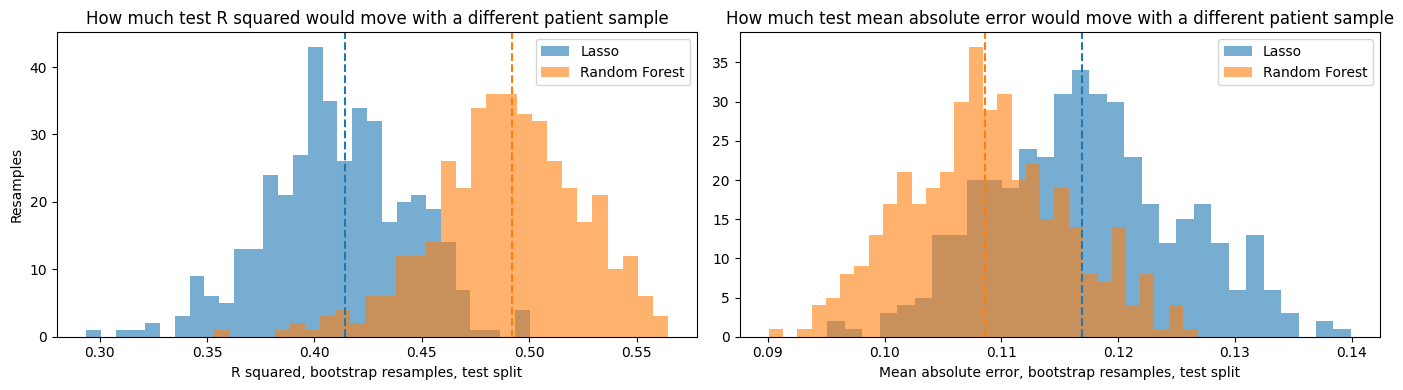

In [1]:
def make_r2_metric(model, scaler=None):
    def metric(d):
        return du.evaluate_regression(model, d[feature_cols], d['RISK_SCORE'], scaler=scaler)['r2']
    return metric

def make_mae_metric(model, scaler=None):
    def metric(d):
        return du.evaluate_regression(model, d[feature_cols], d['RISK_SCORE'], scaler=scaler)['mae']
    return metric

lasso_train_r2_point, lasso_train_r2_lo, lasso_train_r2_hi, _ = du.bootstrap_ci(train_model_data, make_r2_metric(lasso_model, lasso_scaler), id_col='RID')
lasso_train_mae_point, lasso_train_mae_lo, lasso_train_mae_hi, _ = du.bootstrap_ci(train_model_data, make_mae_metric(lasso_model, lasso_scaler), id_col='RID')
lasso_test_r2_point, lasso_test_r2_lo, lasso_test_r2_hi, lasso_test_r2_samples = du.bootstrap_ci(test_model_data, make_r2_metric(lasso_model, lasso_scaler), id_col='RID')
lasso_test_mae_point, lasso_test_mae_lo, lasso_test_mae_hi, lasso_test_mae_samples = du.bootstrap_ci(test_model_data, make_mae_metric(lasso_model, lasso_scaler), id_col='RID')

forest_train_r2_point, forest_train_r2_lo, forest_train_r2_hi, _ = du.bootstrap_ci(train_model_data, make_r2_metric(forest_model), id_col='RID')
forest_train_mae_point, forest_train_mae_lo, forest_train_mae_hi, _ = du.bootstrap_ci(train_model_data, make_mae_metric(forest_model), id_col='RID')
forest_test_r2_point, forest_test_r2_lo, forest_test_r2_hi, forest_test_r2_samples = du.bootstrap_ci(test_model_data, make_r2_metric(forest_model), id_col='RID')
forest_test_mae_point, forest_test_mae_lo, forest_test_mae_hi, forest_test_mae_samples = du.bootstrap_ci(test_model_data, make_mae_metric(forest_model), id_col='RID')

print(f'Lasso,         train, r2 {lasso_train_r2_point:.3f}, 95% CI [{lasso_train_r2_lo:.3f}, {lasso_train_r2_hi:.3f}], '
      f'mae {lasso_train_mae_point:.3f}, 95% CI [{lasso_train_mae_lo:.3f}, {lasso_train_mae_hi:.3f}]')
print(f'Lasso,         test,  r2 {lasso_test_r2_point:.3f}, 95% CI [{lasso_test_r2_lo:.3f}, {lasso_test_r2_hi:.3f}], '
      f'mae {lasso_test_mae_point:.3f}, 95% CI [{lasso_test_mae_lo:.3f}, {lasso_test_mae_hi:.3f}]')
print(f'Random Forest, train, r2 {forest_train_r2_point:.3f}, 95% CI [{forest_train_r2_lo:.3f}, {forest_train_r2_hi:.3f}], '
      f'mae {forest_train_mae_point:.3f}, 95% CI [{forest_train_mae_lo:.3f}, {forest_train_mae_hi:.3f}]')
print(f'Random Forest, test,  r2 {forest_test_r2_point:.3f}, 95% CI [{forest_test_r2_lo:.3f}, {forest_test_r2_hi:.3f}], '
      f'mae {forest_test_mae_point:.3f}, 95% CI [{forest_test_mae_lo:.3f}, {forest_test_mae_hi:.3f}]')

fig, axes = plt.subplots(1, 2, figsize=figsize)

axes[0].hist(lasso_test_r2_samples, bins=30, alpha=0.6, label='Lasso')
axes[0].hist(forest_test_r2_samples, bins=30, alpha=0.6, label='Random Forest')
axes[0].axvline(lasso_test_r2_point, color='C0', linestyle='--')
axes[0].axvline(forest_test_r2_point, color='C1', linestyle='--')
axes[0].set_xlabel('R squared, bootstrap resamples, test split')
axes[0].set_ylabel('Resamples')
axes[0].set_title('How much test R squared would move with a different patient sample')
axes[0].legend()

axes[1].hist(lasso_test_mae_samples, bins=30, alpha=0.6, label='Lasso')
axes[1].hist(forest_test_mae_samples, bins=30, alpha=0.6, label='Random Forest')
axes[1].axvline(lasso_test_mae_point, color='C0', linestyle='--')
axes[1].axvline(forest_test_mae_point, color='C1', linestyle='--')
axes[1].set_xlabel('Mean absolute error, bootstrap resamples, test split')
axes[1].set_title('How much test mean absolute error would move with a different patient sample')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="sec5"></a>

## 5. Saving The Standardized Result

One row per method and per split, four in total, lasso train and test and random_forest train and test, appended to the shared results/decision_support/approach_comparison.csv, read later by comparison.ipynb alongside the other approaches. append_approach_result is idempotent per approach and split, rerunning this notebook replaces its own four rows rather than piling up duplicates. The confidence intervals from the section above are logged alongside both point estimates.

In [1]:
lasso_train_ci = {'r2': (lasso_train_r2_lo, lasso_train_r2_hi), 'mae': (lasso_train_mae_lo, lasso_train_mae_hi)}
lasso_test_ci = {'r2': (lasso_test_r2_lo, lasso_test_r2_hi), 'mae': (lasso_test_mae_lo, lasso_test_mae_hi)}
forest_train_ci = {'r2': (forest_train_r2_lo, forest_train_r2_hi), 'mae': (forest_train_mae_lo, forest_train_mae_hi)}
forest_test_ci = {'r2': (forest_test_r2_lo, forest_test_r2_hi), 'mae': (forest_test_mae_lo, forest_test_mae_hi)}

du.append_approach_result(
    results_path, approach='lasso', approach_group='attribution',
    split='train', n_rows=len(train_model_data),
    r2=lasso_train_metrics['r2'], mae=lasso_train_metrics['mae'], ci=lasso_train_ci,
    notes=f'Signed linear attribution, alpha=0.01, over {len(feature_cols)} biomarkers.',
)
du.append_approach_result(
    results_path, approach='lasso', approach_group='attribution',
    split='test', n_rows=len(test_model_data),
    r2=lasso_test_metrics['r2'], mae=lasso_test_metrics['mae'], ci=lasso_test_ci,
    notes=f'Signed linear attribution, alpha=0.01, over {len(feature_cols)} biomarkers.',
)
du.append_approach_result(
    results_path, approach='random_forest', approach_group='attribution',
    split='train', n_rows=len(train_model_data),
    r2=forest_train_metrics['r2'], mae=forest_train_metrics['mae'], ci=forest_train_ci,
    notes='Nonlinear attribution, 200 trees, max depth 4, feature_importances_ available on the fitted model.',
)
result_row = du.append_approach_result(
    results_path, approach='random_forest', approach_group='attribution',
    split='test', n_rows=len(test_model_data),
    r2=forest_test_metrics['r2'], mae=forest_test_metrics['mae'], ci=forest_test_ci,
    notes='Nonlinear attribution, 200 trees, max depth 4, feature_importances_ available on the fitted model.',
)
result_row

,approach,approach_group,split,n_rows,total_cost,over_threshold_count,didi,catch_rate,r2,mae,...,didi_ci_high,catch_rate_ci_low,catch_rate_ci_high,r2_ci_low,r2_ci_high,mae_ci_low,mae_ci_high,auc_ci_low,auc_ci_high,notes
0,lasso,attribution,train,2048,NaN,NaN,NaN,NaN,0.290228,0.132077,...,NaN,NaN,NaN,0.242719,0.328963,0.122344,0.141936,NaN,NaN,"Signed linear attribution, alpha=0.01, over 8 ..."
1,lasso,attribution,test,753,NaN,NaN,NaN,NaN,0.414381,0.116919,...,NaN,NaN,NaN,0.344180,0.466635,0.102641,0.132866,NaN,NaN,"Signed linear attribution, alpha=0.01, over 8 ..."
2,random_forest,attribution,train,2048,NaN,NaN,NaN,NaN,0.440444,0.114314,...,NaN,NaN,NaN,0.398936,0.472858,0.106378,0.122876,NaN,NaN,"Nonlinear attribution, 200 trees, max depth 4,..."
3,random_forest,attribution,test,753,NaN,NaN,NaN,NaN,0.492007,0.108632,...,NaN,NaN,NaN,0.415581,0.548446,0.095987,0.122486,NaN,NaN,"Nonlinear attribution, 200 trees, max depth 4,..."


<a id="sec6"></a>

## 6. Checking A Clean CSF Subset

ABETA_RATIO, TAU, and PTAU are final.csv's three sparsest columns, forward_fill_by_patient carries each forward and backward across a patient's own visits before feature_cols above ever sees them, real readings from a different visit standing in for a missing one, never an invented value, but still not that specific row's own measurement. Only 6.7 percent of rows carry all three CSF values as an actual direct reading, so most of the CSF signal feeding the ranking above did travel across at least one visit gap first.

The question this section actually answers is narrower than it might sound, not whether ABETA_RATIO, TAU, and PTAU matter, the ranking above already answers that, but whether the forward fill itself is quietly inflating or reshaping how much they seem to matter, by refitting the same Lasso model on only the rows with a direct CSF reading and reading the two weight vectors side by side.

In [2]:
raw_data = pd.read_csv(data_path)
csf_cols = ['ABETA_RATIO', 'TAU', 'PTAU']
clean_csf_data = raw_data.dropna(subset=csf_cols).copy()
print(f'{len(clean_csf_data)} rows, {clean_csf_data.RID.nunique()} patients, '
      f'carry a direct reading for all three CSF columns, out of {len(raw_data)} rows total.')

clean_csf_data['DIAGNOSIS_MCI'] = (clean_csf_data['DIAGNOSIS'] == 2).astype(float)
clean_csf_data['DIAGNOSIS_DEMENTIA'] = (clean_csf_data['DIAGNOSIS'] == 3).astype(float)
clean_csf_data['AMYLOID_POSITIVE'] = (clean_csf_data['AMYLOID_STATUS'] == 1).astype(float)
clean_csf_data['AMYLOID_UNKNOWN'] = clean_csf_data['AMYLOID_STATUS'].isna().astype(float)

clean_train_df, clean_test_df = du.subject_train_test_split(clean_csf_data, test_fraction=0.25, random_state=42)
clean_train_df = clean_train_df.copy()
clean_test_df = clean_test_df.copy()
print(f'Train, {len(clean_train_df)} rows, {clean_train_df.RID.nunique()} patients')
print(f'Test,  {len(clean_test_df)} rows, {clean_test_df.RID.nunique()} patients')

# RISK_SCORE is rebuilt from scratch here rather than sliced out of
# train_df above, since train_df's own RISK_SCORE column came from a
# fallback estimator fit on the full, forward filled training split,
# a different fallback than this smaller, unfilled subset would fit on
# its own. Rebuilding end to end keeps this section a clean, self
# contained comparison rather than one that mixes a model trained on
# one population with a feature set drawn from another.
clean_fallback_train_outcomes = du.compute_diagnosis_worsening(
    clean_train_df, id_col='RID', date_col='EXAMDATE_DX', diagnosis_col='DIAGNOSIS',
)
clean_fallback_train_data = clean_fallback_train_outcomes[clean_fallback_train_outcomes['HAS_NEXT_VISIT']]
clean_fallback_model, clean_fallback_scaler = du.fit_logistic_baseline(
    clean_fallback_train_data[hazard_features],
    clean_fallback_train_data['DIAGNOSIS_WORSENED_NEXT'],
)
clean_train_df['FALLBACK_RISK_SCORE'] = clean_fallback_model.predict_proba(
    clean_fallback_scaler.transform(clean_train_df[hazard_features]))[:, 1]
clean_test_df['FALLBACK_RISK_SCORE'] = clean_fallback_model.predict_proba(
    clean_fallback_scaler.transform(clean_test_df[hazard_features]))[:, 1]

clean_train_df = clean_train_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
clean_test_df = clean_test_df.merge(hazard_estimates, on=['RID', 'VISCODE2_norm'], how='left')
clean_train_df['RISK_SCORE'] = clean_train_df['HAZARD_ESTIMATE'].fillna(clean_train_df['FALLBACK_RISK_SCORE'])
clean_test_df['RISK_SCORE'] = clean_test_df['HAZARD_ESTIMATE'].fillna(clean_test_df['FALLBACK_RISK_SCORE'])

clean_train_model_data = clean_train_df.dropna(subset=feature_cols + ['RISK_SCORE'])
clean_test_model_data = clean_test_df.dropna(subset=feature_cols + ['RISK_SCORE'])


908 rows, 564 patients, carry a direct reading for all three CSF columns, out of 13827 rows total.
Train, 664 rows, 423 patients
Test,  244 rows, 141 patients


In [3]:
clean_lasso_model, clean_lasso_scaler = du.fit_lasso_baseline(
    clean_train_model_data[feature_cols],
    clean_train_model_data['RISK_SCORE'],
    alpha=0.01,
)

clean_lasso_train_r2_point, clean_lasso_train_r2_lo, clean_lasso_train_r2_hi, _ = du.bootstrap_ci(
    clean_train_model_data, make_r2_metric(clean_lasso_model, clean_lasso_scaler), id_col='RID')
clean_lasso_test_r2_point, clean_lasso_test_r2_lo, clean_lasso_test_r2_hi, _ = du.bootstrap_ci(
    clean_test_model_data, make_r2_metric(clean_lasso_model, clean_lasso_scaler), id_col='RID')
clean_lasso_train_mae_point, clean_lasso_train_mae_lo, clean_lasso_train_mae_hi, _ = du.bootstrap_ci(
    clean_train_model_data, make_mae_metric(clean_lasso_model, clean_lasso_scaler), id_col='RID')
clean_lasso_test_mae_point, clean_lasso_test_mae_lo, clean_lasso_test_mae_hi, _ = du.bootstrap_ci(
    clean_test_model_data, make_mae_metric(clean_lasso_model, clean_lasso_scaler), id_col='RID')

print(f'Clean CSF subset Lasso, train, r2 {clean_lasso_train_r2_point:.3f}, '
      f'95% CI [{clean_lasso_train_r2_lo:.3f}, {clean_lasso_train_r2_hi:.3f}], '
      f'mae {clean_lasso_train_mae_point:.3f}, 95% CI [{clean_lasso_train_mae_lo:.3f}, {clean_lasso_train_mae_hi:.3f}]')
print(f'Clean CSF subset Lasso, test,  r2 {clean_lasso_test_r2_point:.3f}, '
      f'95% CI [{clean_lasso_test_r2_lo:.3f}, {clean_lasso_test_r2_hi:.3f}], '
      f'mae {clean_lasso_test_mae_point:.3f}, 95% CI [{clean_lasso_test_mae_lo:.3f}, {clean_lasso_test_mae_hi:.3f}]')
print(f'For comparison, the full, forward filled Lasso above scored '
      f'test r2 {lasso_test_r2_point:.3f}, 95% CI [{lasso_test_r2_lo:.3f}, {lasso_test_r2_hi:.3f}].')


Clean CSF subset Lasso, train, r2 0.293, 95% CI [0.222, 0.331], mae 0.136, 95% CI [0.127, 0.146]
Clean CSF subset Lasso, test,  r2 0.216, 95% CI [0.096, 0.279], mae 0.157, 95% CI [0.136, 0.179]
For comparison, the full, forward filled Lasso above scored test r2 0.414, 95% CI [0.344, 0.467].


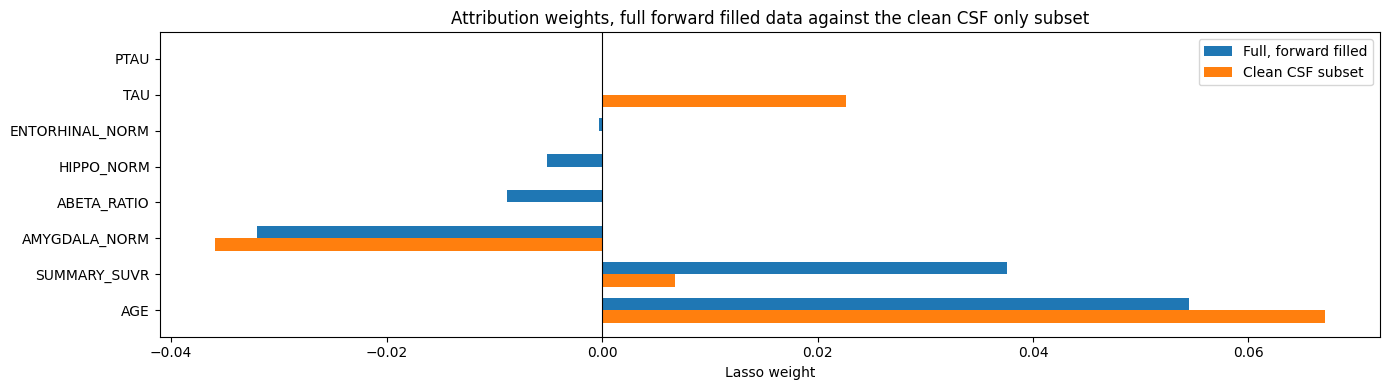

,full_forward_filled,clean_csf_subset
AGE,0.054481,0.067060
SUMMARY_SUVR,0.037578,0.006800
AMYGDALA_NORM,-0.031986,-0.035910
ABETA_RATIO,-0.008831,-0.000000
HIPPO_NORM,-0.005085,-0.000000
ENTORHINAL_NORM,-0.000274,-0.000000
TAU,0.000000,0.022647
PTAU,0.000000,0.000000


In [4]:
full_weights = pd.Series(lasso_model.coef_, index=feature_cols, name='full_forward_filled')
clean_weights = pd.Series(clean_lasso_model.coef_, index=feature_cols, name='clean_csf_subset')
weight_comparison = pd.concat([full_weights, clean_weights], axis=1)
weight_comparison = weight_comparison.reindex(
    weight_comparison['full_forward_filled'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=figsize)
y_positions = np.arange(len(weight_comparison))
bar_height = 0.35
ax.barh(y_positions + bar_height / 2, weight_comparison['full_forward_filled'], height=bar_height, label='Full, forward filled')
ax.barh(y_positions - bar_height / 2, weight_comparison['clean_csf_subset'], height=bar_height, label='Clean CSF subset')
ax.set_yticks(y_positions)
ax.set_yticklabels(weight_comparison.index)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso weight')
ax.set_title('Attribution weights, full forward filled data against the clean CSF only subset')
ax.legend()
plt.tight_layout()
plt.show()

weight_comparison


**Read agreement in sign and rough size as the forward fill not meaningfully reshaping this notebook's own ranking, a biomarker changing sign or moving several places is the signal actually worth chasing.** The clean subset above is small, well under a tenth of the full training data, so its own confidence interval two cells up is wide, a single point estimate here disagreeing with the full model is expected sampling noise more often than it is a real forward fill artifact, the same reasoning section 4 already applies to comparing Lasso against Random Forest. AGE, HIPPO_NORM, ENTORHINAL_NORM, AMYGDALA_NORM, and SUMMARY_SUVR never depend on forward filling ABETA_RATIO, TAU, or PTAU at all, so any of those five moving here would be the more surprising finding, a sign the smaller subject population itself differs from the full one in some other way.

In [5]:
import dill as _dill
import os as _os
import sys as _sys
_checkpoint = {k: v for k, v in globals().items() if not k.startswith('_') and k not in ('In', 'Out', 'get_ipython', 'exit', 'quit')}
with open('1_global.ipynb.kernel_checkpoint.pkl.tmp', 'wb') as _f:
    _dill.dump(_checkpoint, _f)
_os.replace('1_global.ipynb.kernel_checkpoint.pkl.tmp', '1_global.ipynb.kernel_checkpoint.pkl')
with open('1_global.ipynb.kernel_checkpoint.syspath.json', 'w') as _pf:
    import json as _json
    _json.dump(list(_sys.path), _pf)
del _checkpoint, _f, _dill, _os, _sys, _pf, _json
